In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

In [2]:
df_train = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17499636 entries, 0 to 25661583
Data columns (total 19 columns):
 #   Column         Dtype         
---  ------         -----         
 0   status         int64         
 1   gender         object        
 2   firstName      object        
 3   level          object        
 4   lastName       object        
 5   userId         object        
 6   ts             int64         
 7   auth           object        
 8   page           object        
 9   sessionId      int64         
 10  location       object        
 11  itemInSession  int64         
 12  userAgent      object        
 13  method         object        
 14  length         float64       
 15  song           object        
 16  artist         object        
 17  time           datetime64[us]
 18  registration   datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(4), object(12)
memory usage: 2.6+ GB


In [4]:
df_train["date"] = pd.to_datetime(df_train["time"]).dt.date

In [5]:
df_train[df_train["date"] == datetime.date(2018, 11, 20)]

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration,date
16470805,200,F,Gabriela,paid,Smith,1062319,1542672000000,Logged In,NextSong,204650,"Beaver Dam, WI",2,Mozilla/5.0 (X11; Ubuntu; Linux i686; rv:31.0)...,PUT,155.11465,Overture,Devotchka,2018-11-20,2018-09-29 18:11:03,2018-11-20
22612207,200,M,Ryan,paid,Pugh,1909263,1542672000000,Logged In,NextSong,28993,"Oklahoma City, OK",3,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,PUT,140.87791,Got That Feeling,Faith No More,2018-11-20,2018-09-15 01:42:02,2018-11-20
25661643,200,M,Asher,paid,White,1030345,1542672000000,Logged In,NextSong,36771,"Nashville-Davidson--Murfreesboro--Franklin, TN",148,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,346.74893,Themata,Karnivool,2018-11-20,2018-08-15 21:36:16,2018-11-20


In [13]:
df = df_train.copy()

In [14]:
df["time"] = pd.to_datetime(df["time"])

In [15]:
df["date"] = df["time"].dt.date
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year
df["day_of_week"] = df["time"].dt.day_of_week + 1

# Get Holiday
# df["day_of_week"] = df["time"].dt.isocalendar()

In [6]:
df_total_time_df = df_train.groupby("date")["length"].sum().reset_index()

In [9]:
df_total_time_df.sample(10)

,date,length
7,2018-10-08,8.149864e+07
0,2018-10-01,7.186293e+07
46,2018-11-16,7.340204e+07
4,2018-10-05,8.284738e+07
43,2018-11-13,7.776709e+07
28,2018-10-29,7.603862e+07
26,2018-10-27,5.433073e+07
35,2018-11-05,6.980084e+07
22,2018-10-23,8.490264e+07
31,2018-11-01,8.025979e+07


In [16]:
df["Cancelled"] = df["page"] == "Cancellation Confirmation"
df["Cancelled"] = df["Cancelled"].astype(int)

In [17]:
df_cancelled_sum = df.groupby(["date"])["Cancelled"].sum().reset_index()

In [21]:
df_cancelled_sum.head(10)

,date,Cancelled
0,2018-10-01,117
1,2018-10-02,129
2,2018-10-03,129
3,2018-10-04,126
4,2018-10-05,115
5,2018-10-06,56
6,2018-10-07,56
7,2018-10-08,108
8,2018-10-09,120
9,2018-10-10,122


In [18]:
df_cancelled_sum.columns

Index(['date', 'Cancelled'], dtype='object')

In [22]:
df_total_time_df.head()

,date,length
0,2018-10-01,7.186293e+07
1,2018-10-02,8.021933e+07
2,2018-10-03,8.071104e+07
3,2018-10-04,8.749061e+07
4,2018-10-05,8.284738e+07


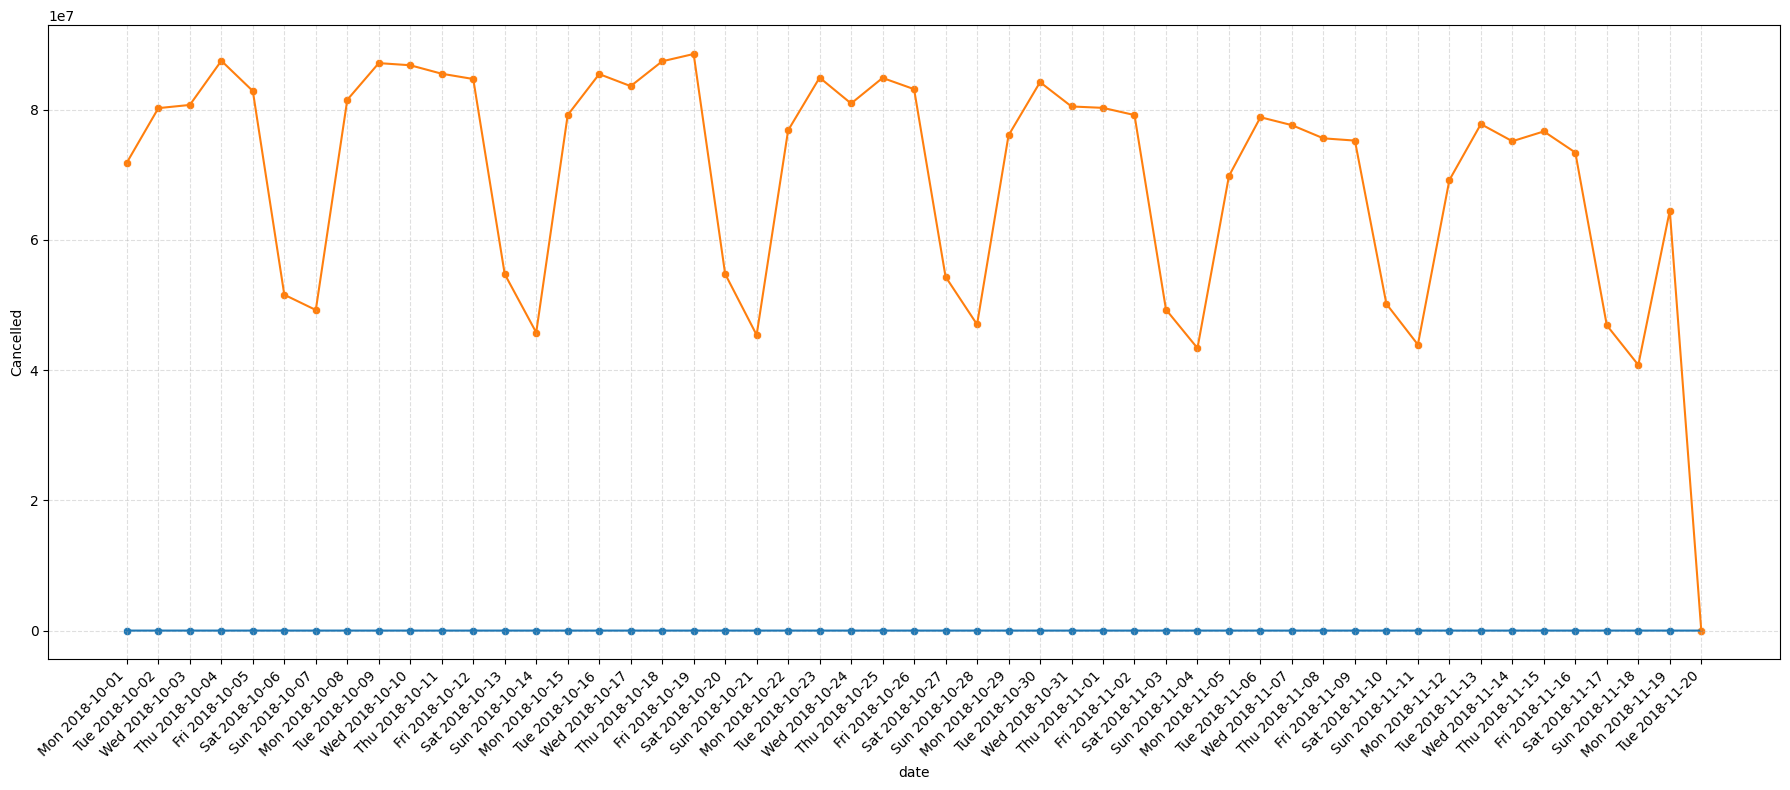

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df_cancelled_sum["date"] = pd.to_datetime(df_cancelled_sum["date"])

fig, ax = plt.subplots(figsize=(18, 8))

sns.scatterplot(data=df_cancelled_sum, x="date", y="Cancelled", ax = ax)
sns.scatterplot(data=df_total_time_df, x="date", y ="length", ax = ax)
sns.lineplot(df_cancelled_sum, x = "date", y = "Cancelled", ax = ax)
sns.lineplot(data=df_total_time_df, x="date", y ="length", ax = ax)

ax.grid(True, which="both", axis="both", linestyle="--", alpha=0.4)

# all dates as ticks + weekday name
ax.set_xticks(df_cancelled_sum["date"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %Y-%m-%d"))  # e.g. Mon 2018-10-01

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()


In [ ]:
# Amount listened to music in the last 7 days

temp = df[["userId", "date", "length", "page"]].copy()

temp["time_one_app"] = temp.groupby(["userId"])["length"].transform("sum")

temp["time_on_app_minutes"] = temp["time_one_app"] / 60


temp["Canceled"] = temp["page"] == "Cancellation Confirmed"
temp["Canceled"] = temp["Canceled"].astype(int)

